# Evaluation and Comparison

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cpu
PyTorch: 2.12.0


In [3]:
DATA_DIR = Path("../data/raw/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

train_paths = sorted(list(TRAIN_DIR.glob("*/*.jpg")))
val_paths = sorted(list(VAL_DIR.glob("*/*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*/*.jpg")))

print(f"Train images: {len(train_paths)}")
print(f"Val images:   {len(val_paths)}")
print(f"Test images:  {len(test_paths)}")

Train images: 18400
Val images:   2800
Test images:  2800


In [4]:
TARGET_SIZE = (256, 128)

def preprocess_image(path, target_size=TARGET_SIZE):
    img = Image.open(path).convert("L")
    img = img.resize(target_size, resample=Image.BILINEAR)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr


def horizontal_stripe_mask(shape, stripe_height=24):
    h, w = shape
    mask = np.ones((h, w), dtype=np.float32)
    center = h // 2
    top = center - stripe_height // 2
    mask[top:top+stripe_height, :] = 0.0
    return mask

In [5]:
def masked_mse(original, reconstruction, mask):
    missing_region = mask == 0
    return np.mean((original[missing_region] - reconstruction[missing_region]) ** 2)


def masked_mae(original, reconstruction, mask):
    missing_region = mask == 0
    return np.mean(np.abs(original[missing_region] - reconstruction[missing_region]))


def psnr(original, reconstruction):
    mse = np.mean((original - reconstruction) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(1.0 / np.sqrt(mse))

In [6]:
def gaussian_reconstruction(masked, mask):
    blurred = cv2.GaussianBlur(masked, ksize=(21, 21), sigmaX=0)
    recon = masked.copy()
    recon[mask == 0] = blurred[mask == 0]
    return recon


def telea_reconstruction(masked, mask):
    masked_uint8 = (masked * 255).astype(np.uint8)
    opencv_mask = ((1 - mask) * 255).astype(np.uint8)
    
    recon = cv2.inpaint(
        masked_uint8,
        opencv_mask,
        inpaintRadius=3,
        flags=cv2.INPAINT_TELEA
    )
    
    return recon.astype(np.float32) / 255.0


def pde_diffusion_reconstruction(masked_image, mask, n_iters=500, dt=0.1):
    u = masked_image.copy()
    
    known_pixels = mask == 1
    missing_pixels = mask == 0
    
    for _ in range(n_iters):
        laplacian = (
            np.roll(u, 1, axis=0)
            + np.roll(u, -1, axis=0)
            + np.roll(u, 1, axis=1)
            + np.roll(u, -1, axis=1)
            - 4 * u
        )
        
        u[missing_pixels] = u[missing_pixels] + dt * laplacian[missing_pixels]
        u[known_pixels] = masked_image[known_pixels]
    
    return u

In [7]:
# DDPM schedule

T = 1000
beta_start = 1e-4
beta_end = 2e-2

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

In [8]:
# Timestep embedding
import math

class SinusoidalPositionEmbeddings(nn.Module):
    
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )
        
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        
        return embeddings

In [9]:
# Conditional DDPM model

class ConditionalTimeDDPM(nn.Module):
    
    def __init__(self, time_emb_dim=32):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        
        self.deconv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.deconv2 = nn.Conv2d(64, 32, 3, padding=1)
        self.deconv3 = nn.Conv2d(32, 1, 3, padding=1)
        
        self.relu = nn.ReLU()
        self.time_proj = nn.Linear(time_emb_dim, 64)
    
    def forward(self, x_t, masked_image, mask, t):
        x = torch.cat([x_t, masked_image, mask], dim=1)
        
        t_emb = self.time_mlp(t.float())
        
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        h = self.relu(self.conv3(h))
        
        t_proj = self.time_proj(t_emb)[:, :, None, None]
        h = h + t_proj
        
        h = self.relu(self.deconv1(h))
        h = self.relu(self.deconv2(h))
        
        return self.deconv3(h)

In [10]:
# Load DDPM checkpoint

checkpoint_path = Path("../results/conditional_ddpm_masked_loss_1000steps.pt")

cond_model = ConditionalTimeDDPM().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

cond_model.load_state_dict(checkpoint["model_state_dict"])
cond_model.eval()

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [11]:
@torch.no_grad()
def sample_conditional_inpaint(model, masked_image, mask, sample_steps=100):
    model.eval()
    
    x = torch.randn_like(masked_image)
    x = mask * masked_image + (1 - mask) * x
    
    timesteps = torch.linspace(
        T - 1,
        0,
        sample_steps,
        device=device
    ).long()
    
    for i in range(len(timesteps) - 1):
        t = timesteps[i]
        t_prev = timesteps[i + 1]
        
        t_batch = torch.full(
            (x.shape[0],),
            t,
            device=device,
            dtype=torch.long
        )
        
        pred_noise = model(x, masked_image, mask, t_batch)
        
        alpha_bar_t = alpha_bars[t].view(1, 1, 1, 1)
        alpha_bar_prev = alpha_bars[t_prev].view(1, 1, 1, 1)
        
        x0_pred = (
            x - torch.sqrt(1.0 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)
        
        x = (
            torch.sqrt(alpha_bar_prev) * x0_pred
            + torch.sqrt(1.0 - alpha_bar_prev) * pred_noise
        )
        
        x = mask * masked_image + (1 - mask) * x
    
    return x.clamp(0, 1)

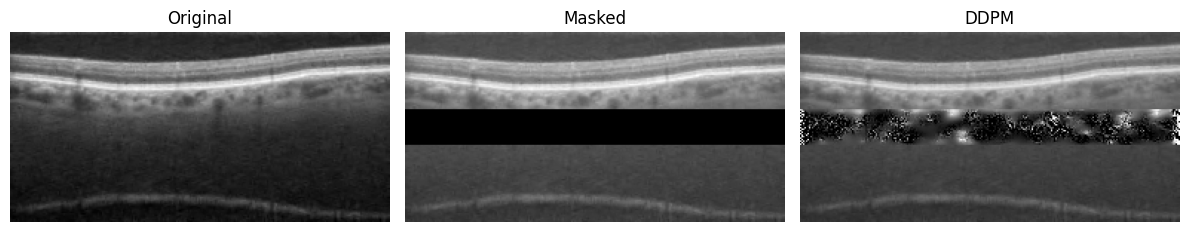

In [12]:
path = test_paths[0]

original = preprocess_image(path)
mask = horizontal_stripe_mask(original.shape, stripe_height=24)
masked = original * mask

masked_tensor = torch.tensor(masked).unsqueeze(0).unsqueeze(0).float().to(device)
mask_tensor = torch.tensor(mask).unsqueeze(0).unsqueeze(0).float().to(device)

ddpm_recon = sample_conditional_inpaint(
    cond_model,
    masked_tensor,
    mask_tensor,
    sample_steps=100
)

ddpm_recon_np = ddpm_recon[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked, cmap="gray")
axes[1].set_title("Masked")
axes[1].axis("off")

axes[2].imshow(ddpm_recon_np, cmap="gray")
axes[2].set_title("DDPM")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [13]:
def ddpm_reconstruction(original, mask):
    
    masked = original * mask
    
    masked_tensor = (
        torch.tensor(masked)
        .unsqueeze(0)
        .unsqueeze(0)
        .float()
        .to(device)
    )
    
    mask_tensor = (
        torch.tensor(mask)
        .unsqueeze(0)
        .unsqueeze(0)
        .float()
        .to(device)
    )
    
    recon = sample_conditional_inpaint(
        cond_model,
        masked_tensor,
        mask_tensor,
        sample_steps=100
    )
    
    return recon[0, 0].cpu().numpy()

In [14]:
# Full comparison evaluation

def evaluate_all_methods(image_paths, n_samples=25):
    
    rows = []
    
    for i, path in enumerate(image_paths[:n_samples]):
        
        print(f"Processing {i+1}/{n_samples}")
        
        original = preprocess_image(path)
        
        mask = horizontal_stripe_mask(
            original.shape,
            stripe_height=24
        )
        
        masked = original * mask
        
        zero = masked.copy()
        
        gaussian = gaussian_reconstruction(masked, mask)
        
        pde = pde_diffusion_reconstruction(masked, mask)
        
        telea = telea_reconstruction(masked, mask)
        
        ddpm = ddpm_reconstruction(original, mask)
        
        rows.append({
            "idx": i,
            
            "zero_mse": masked_mse(original, zero, mask),
            "gaussian_mse": masked_mse(original, gaussian, mask),
            "pde_mse": masked_mse(original, pde, mask),
            "telea_mse": masked_mse(original, telea, mask),
            "ddpm_mse": masked_mse(original, ddpm, mask),
            
            "zero_psnr": psnr(original, zero),
            "gaussian_psnr": psnr(original, gaussian),
            "pde_psnr": psnr(original, pde),
            "telea_psnr": psnr(original, telea),
            "ddpm_psnr": psnr(original, ddpm),
        })
    
    return pd.DataFrame(rows)

In [15]:
all_results = evaluate_all_methods(
    test_paths,
    n_samples=25
)

all_results.describe()

Processing 1/25
Processing 2/25
Processing 3/25
Processing 4/25
Processing 5/25
Processing 6/25
Processing 7/25
Processing 8/25
Processing 9/25
Processing 10/25
Processing 11/25
Processing 12/25
Processing 13/25
Processing 14/25
Processing 15/25
Processing 16/25
Processing 17/25
Processing 18/25
Processing 19/25
Processing 20/25
Processing 21/25
Processing 22/25
Processing 23/25
Processing 24/25
Processing 25/25


,idx,zero_mse,gaussian_mse,pde_mse,telea_mse,ddpm_mse,zero_psnr,gaussian_psnr,pde_psnr,telea_psnr,ddpm_psnr
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,12.000000,0.168830,0.135240,0.032117,0.011193,0.078171,15.146725,16.138763,22.806791,28.576843,18.537106
std,7.359801,0.045997,0.040843,0.019640,0.009961,0.026551,1.168484,1.264829,2.225302,4.350855,1.283397
min,0.000000,0.097356,0.078134,0.012760,0.000569,0.046287,12.717123,13.366128,17.425142,20.978468,15.077200
25%,6.000000,0.135938,0.106638,0.020181,0.003504,0.060209,14.420542,15.406538,20.827049,24.957821,17.977211
50%,12.000000,0.164032,0.124578,0.023066,0.008906,0.068765,15.120697,16.315590,23.640240,27.773254,18.896330
75%,18.000000,0.192728,0.153584,0.044085,0.017030,0.084972,15.936588,16.990871,24.220600,31.823948,19.473339
max,24.000000,0.285290,0.245689,0.096490,0.042575,0.165683,17.386343,18.341564,26.211433,39.720493,20.615383


# Experimental Journal — 05 Evaluation and Comparison

## Objective

The goal of this notebook was to unify all reconstruction methods into a single evaluation framework and directly compare:
- deterministic interpolation methods,
- PDE-based reconstruction,
- and conditional DDPM inpainting.

This notebook marked the first full-system benchmark of the project and focused on:
- quantitative comparison,
- visual inspection,
- identifying strengths and weaknesses of each method,
- and evaluating whether diffusion-based reconstruction was beginning to outperform classical baselines.

---

# Unified Evaluation Pipeline

The notebook evaluated:
- zero-fill reconstruction,
- Gaussian reconstruction,
- PDE diffusion reconstruction,
- Telea inpainting,
- conditional DDPM reconstruction.

All methods were evaluated under:
- identical preprocessing,
- identical stripe corruption,
- and identical reconstruction conditions.

This ensured:
- fair comparison,
- reproducibility,
- and controlled experimentation.

---

# DDPM Evaluation Setup

The notebook loaded the conditional DDPM checkpoint trained previously and reused:
- timestep conditioning,
- masked-image conditioning,
- iterative reverse diffusion sampling,
- and masked-region reconstruction.

The DDPM sampling pipeline used:
- stochastic initialization inside missing regions,
- iterative denoising,
- and conditional guidance from observed anatomy.

This was the first notebook where the DDPM was evaluated directly against all earlier reconstruction methods.

---

# Initial DDPM Reconstruction Results

The first reconstruction tests revealed several important behaviors.

The DDPM was capable of:
- partially reconstructing retinal continuity,
- preserving large-scale brightness structure,
- and generating coarse anatomical patterns.

However, generated regions still contained:
- heavy speckled artifacts,
- unstable texture,
- weak retinal layer reconstruction,
- and incomplete anatomical continuity.

This immediately suggested:
- the diffusion model was learning global structure,
- but sampling quality remained immature.

---

# Full Benchmark Evaluation

The notebook evaluated all reconstruction methods across:
- 25 OCT test images.

For every image:
1. stripe corruption was applied,
2. all reconstruction methods were executed,
3. reconstruction metrics were computed,
4. results were aggregated into a dataframe.

This became the first large-scale comparison across the entire project pipeline.

---

# Major Findings

## Telea Remained the Strongest Overall Baseline

Telea consistently produced:
- the sharpest retinal boundaries,
- the strongest local continuity,
- and the best overall reconstruction quality.

This was an important finding because it showed:
- classical interpolation methods remain extremely competitive for OCT reconstruction.

---

## PDE Reconstruction Improved Smoothness but Oversmoothed Anatomy

The PDE method produced:
- smoother transitions,
- stable reconstruction behavior,
- and coherent low-frequency continuation.

However:
- fine retinal detail disappeared,
- pathology became blurred,
- and layer boundaries weakened significantly.

This confirmed:
- deterministic diffusion alone is insufficient for realistic anatomical reconstruction.

---

## DDPM Reconstruction Showed Partial Semantic Learning

Although the DDPM underperformed Telea quantitatively, it demonstrated several promising behaviors:
- coarse anatomical continuation,
- contextual stripe reconstruction,
- and global retinal structure awareness.

Unlike deterministic methods:
- the DDPM was attempting to generate plausible anatomy rather than simply propagating nearby pixels.

This became one of the most important conceptual distinctions in the project.

---

# Important Scientific Insight

One major realization emerged during evaluation:

Better generative modeling does not necessarily produce lower pixelwise error.

Classical methods:
- directly interpolate nearby structure,
- which often minimizes reconstruction error numerically.

DDPMs:
- attempt to learn a distribution of plausible anatomy,
- which may appear perceptually reasonable even if pixel values differ from the original scan.

This highlighted an important limitation of:
- pure MSE-based evaluation,
- especially for generative biomedical imaging tasks.

---

# DDPM Failure Modes

Several consistent DDPM issues appeared across evaluation samples.

## Speckled Noise Artifacts

Generated stripe regions frequently contained:
- high-frequency noise,
- scattered bright artifacts,
- unstable textures.

This likely resulted from:
- insufficient training duration,
- underdeveloped reverse diffusion dynamics,
- and limited model capacity.

---

## Weak Retinal Layer Continuity

The DDPM often failed to reconstruct:
- sharp retinal boundaries,
- thin anatomical layers,
- and pathology-specific structure.

This suggested:
- the model had not yet learned sufficiently strong anatomical priors.

---

## Sampling Instability

Different reconstructions could vary noticeably between runs.

This reflected:
- stochastic sampling behavior,
- immature denoising convergence,
- and unstable reverse diffusion trajectories.

---

# Project-Wide Insights

Several broader conclusions emerged after integrating all notebooks together.

---

# OCT Inpainting Is Highly Structured

The experiments consistently showed:
- retinal geometry is strongly directional,
- continuity matters substantially,
- and pathology complicates reconstruction significantly.

OCT reconstruction is not simply a texture problem.

It requires:
- anatomical understanding,
- global structure modeling,
- and contextual continuity.

---

# Classical Interpolation Is Surprisingly Strong

One of the biggest surprises in the project was how effective Telea reconstruction remained.

This demonstrated:
- OCT images contain strong local continuity priors,
- and many missing structures can be approximated using neighboring geometry alone.

This established a very strong baseline for future generative approaches.

---

# Diffusion Models Require Much More Optimization

The DDPM pipeline successfully implemented:
- forward diffusion,
- timestep conditioning,
- conditional reconstruction,
- masked-loss training,
- and reverse sampling.

However, successful implementation did not immediately translate into high-quality generation.

The experiments showed that diffusion models require:
- substantially longer training,
- larger architectures,
- and more sophisticated sampling methods

than deterministic reconstruction approaches.

---

# Current Project Limitations

Several important limitations remain across the project as a whole.

---

# Limited Computational Resources

Most experiments were performed:
- on CPU,
- with small batch sizes,
- and relatively lightweight architectures.

This constrained:
- training duration,
- model complexity,
- and sampling quality.

---

# Simplified DDPM Architecture

The implemented DDPM remains relatively minimal.

The current model lacks:
- U-Net structure,
- residual blocks,
- attention layers,
- multi-scale feature propagation,
- advanced conditioning mechanisms.

Modern diffusion systems typically rely heavily on these components.

---

# Limited Training Duration

Even the longest runs remain relatively short for diffusion modeling.

The DDPM likely remains heavily undertrained.

This affects:
- denoising quality,
- sampling stability,
- and anatomical realism.

---

# Synthetic Corruption Only

The project currently focuses on:
- idealized horizontal stripe corruption.

Real OCT corruption is often:
- irregular,
- noisy,
- acquisition-dependent,
- and structurally complex.

---

# Evaluation Limitations

Current evaluation remains heavily pixel-based.

The project does not yet evaluate:
- perceptual realism,
- retinal layer consistency,
- clinical usefulness,
- or uncertainty quality.

---

# Future Extensions for the Project

Several natural next directions emerged from the experiments.

---

# Larger Diffusion Architectures

Future work should explore:
- U-Net DDPMs,
- residual diffusion blocks,
- attention-based conditioning,
- and multi-scale reconstruction pipelines.

---

# Longer Training Schedules

Future experiments should include:
- multi-thousand step optimization,
- checkpoint continuation,
- and larger training schedules.

The current DDPM likely requires substantially more optimization before stable generation emerges.

---

# Improved Sampling Methods

Future reconstruction experiments may include:
- DDIM sampling,
- accelerated reverse diffusion,
- stochastic samplers,
- classifier-free guidance,
- improved noise schedules.

---

# More Realistic Corruption Models

Future corruption strategies may include:
- irregular masks,
- retinal-layer-specific corruption,
- motion artifacts,
- partial acquisition failure,
- scanner noise simulation.

---

# Advanced Biomedical Evaluation

Future evaluation may include:
- SSIM,
- perceptual similarity metrics,
- retinal layer segmentation consistency,
- expert visual grading,
- pathology-aware reconstruction analysis.

---

# Clinical and Research Extensions

Potential long-term extensions include:
- pathology-conditioned reconstruction,
- uncertainty-aware OCT generation,
- anomaly detection,
- progression modeling,
- self-supervised retinal representation learning,
- and generative biomedical imaging research.

---

# Key Experimental Takeaways

## Reconstruction Insights

- Telea remains an extremely strong OCT reconstruction baseline.
- PDE reconstruction provides smooth but oversmoothed anatomy.
- DDPM reconstruction is promising but still immature.

---

## Generative Modeling Insights

- Conditional DDPM pipelines were successfully implemented end-to-end.
- Training stability remains difficult.
- Reverse diffusion quality depends heavily on optimization and architecture.

---

## Project-Level Insights

The project successfully established:
- a full OCT reconstruction pipeline,
- deterministic and generative baselines,
- conditional diffusion infrastructure,
- and a reproducible experimentation framework.

This creates a strong foundation for future:
- biomedical diffusion modeling,
- OCT reconstruction research,
- and generative medical imaging experiments.